<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/BreamAndSmelt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 마켓과 머신러닝

## 생선 분류 문제

### 도미 데이터 준비하기

In [109]:
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

### 빙어 데이터 준비하기

In [110]:
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

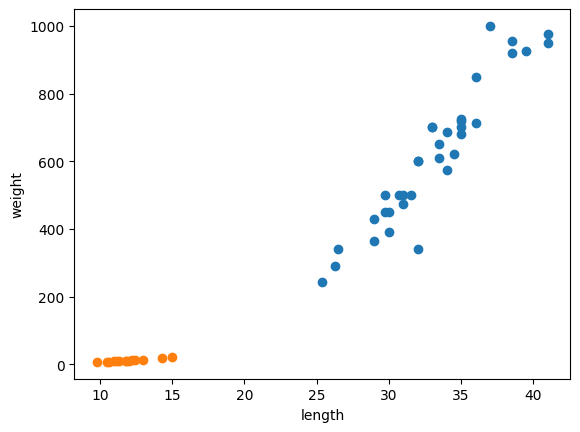

In [111]:
import matplotlib.pyplot as plt # matplotlib의 pyplot 함수를 plt로 줄여서 사용함!

plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)
# scatter() 함수를 연달아 사용해 도미와 빙어 2개의 산점도(scatter plot)를 한 그래프로 그리기
# scatter() 함수는 산점도를 그리는 맷플롯립 함수이다.

plt.xlabel('length') # x축을 길이로.
plt.ylabel('weight') # y축을 무게로.
plt.show()
# 선형적인linear 형태로 나옴.

## 첫 번째 머신러닝 프로그램

<사용할 머신러닝 패키지: 사이킷런 (scikit-learn)>

  이 패키지를 사용하려면 다음과 같이 각 feature의 리스트를 세로로 늘어뜨린 2차원 리스트를 만들어야 한다.

    [ [물고기A의 길이, 물고기A의 무게],
      [물고기B의 길이, 물고기B의 무게],
      ...
      [물고기N의 길이, 물고기N의 무게] ]


In [112]:
# 두 리스트를 합치기
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

In [113]:
fish_data = [[l,w] for l, w in zip(length, weight)]

zip() 함수는 나열된 리스트 각각에서 하나씩 원소를 꺼내 반환함.

In [114]:
fish_target = [1] * 35 + [0] * 14 # 찾으려는 대상인 도미를 1, 그 외인 빙어를 0으로 구분해서 정답을 알려줌
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [115]:
from sklearn.neighbors import KNeighborsClassifier

사이킷런 패키지에서 k-최근접 이웃 알고리즘을 구현한 클래스인 KNeighborsClassifier를 임포트.

In [116]:
kn = KNeighborsClassifier()

임포트한 KNeighborsClassifier 클래스의 객체 kn를 만듬

위 객체 kn에 fish_data와 fish_target을 전달하여 도미를 찾기 위한 기준을 학습시킴.

이러한 과정을 머신러닝에서 training훈련이라고 부름
사이킷런에서는 fit() 메서드가 이러한 역할을 함


In [117]:
kn.fit(fish_data, fish_target) #fit() 메서드에 fish_data와 fish_target을 순서대로 전달.

KNeighborsClassifier()

fit() 메서드는 주어진 데이터로 알고리즘을 '훈련'할 때 쓰인다.

이제 객체(또는 모델) kn이 얼마나 잘 훈련되있는지 평가하기.
사이킷런에서 모델을 평가하는 메서드는 score() 메서드이다.
0과 1 사이의 값을 반환함.

1: 모든 데이터를 정확히 맞췄다는 것 => 정확도 accuracy가 100%라는 것!!! 즉 도미와 빙어를 완벽히 분류했다는 것이다.

0.5: 딱 절반만 맞춘 것

In [118]:
kn.score(fish_data, fish_target) # 훈련된 사이킷런 모델이 잘 훈련됬는지 평가. (성능을 측정)

1.0

<여기서 모델이란?>

머신러닝 알고리즘을 구현한 프로그램을 모델(model)이라고 부름.
또는 프로그램이 아니더라도 알고리즘을 수식 등으로 구체화하여 표현한 것을 모델이라 부름.

ex) 스팸 메일을 걸러내기 위해 k-최근접 이웃 모델을 사용해봅시다.

새로운 물고기를 들여왔다. 이 물고기가 도미인지 빙어인지 예측해보자!

In [119]:
kn.predict([[30,600]]) # 반환되는 값이 1이지 찾으려는 대상인 도미, 0이면 빙어이다.
# predict() 메서드는 사이킷런 모델을 '훈련'하고 '예측'할 때 사용함

array([1])

### k-최근접 이웃 알고리즘

In [120]:
# k-최근접 이웃 알고리즘은 새로운 데이터에서 가장 가까운 직선거리에 어떤 데이터가 있는지 살피기만 하면 된다.
# 단점: 데이터가 아주 많은 경우엔 메모리가 많이 필요하고, 직선거리를 계산하는데도 많은 시간이 필요함.

# 사이킷런의 KNeighborsClassifier 클래스도 마찬가지이다.
# 이 클래스는 _fix_X 속성에 우리가 전달한 fish_data를 모두 가지고 있고,
print(kn._fit_X)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [121]:
# _y 속성에 fish_target(정답)을 가지고 있다.
print(kn._y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]


즉 실제로 k-최근접 이웃 알고리즘은 무언가 훈련되는 게 없다.

fit() 메서드에 전달한 데이터를 모두 저장하고 있다가,
새로운 데이터가 등장하면 가장 가까운 데이터를 참고하여 도미인지 빙어인지를 구분함!

그럼 가까운 몇 개의 데이터를 참고하는가? 정하기 나름.
KNeighborsClassifier의 기본값은 5.

이 기준은 n_neighbors 매개변수로 바꿀 수 있다.

In [122]:
kn49 = KNeighborsClassifier(n_neighbors=49) # 참고 데이터를 49개로 한 kn49 모델 객체

# 가장 가까운 데이터 49개를 사용하는 k-최근접 이웃 모델에 fish_data를 적용하면,
# fish_data에 있는 모든 생선(35+14=49)을 사용하여 예측하게 됨.
# 즉, fish_data의 데이터 49개 중에 도미가 35개로 다수를 차지하므로,
# 어떤 데이터를 넣어도 무조건 도미로 예측할 것이다..
kn49.fit(fish_data, fish_target) # fit() 메서드는 주어진 데이터로 알고리즘을 훈련함
kn49.score(fish_data, fish_target) # 모델이 잘 훈련됬는지 평가. 0과 1 사이의 값을 반환함.

0.7142857142857143

In [123]:
# kn49 모델은 49개 중 도미만 올바르게 맞히기 때문에 정확도를 계산하면 score() 메서드와 같은 값을 얻을 수 있다.
print(35/49)
# 즉, n_neighbors 매개변수를 49로 두는 것은 좋지 않다는 것을 알 수 있다.
# 기본값을 5로 한 모델을 사용하자.

0.7142857142857143


<정확도>
정확도는 정확한 답을 몇 개 맞혔는지 백분율로 나타낸 값이다.
사이킷런에서는 0~1 사이의 값으로 출력된다.

정확도는 (정확히 맞힌 개수) / (전체 데이터 개수)

In [124]:
# <결괏값은 한번만 출력>
kn49.score(fish_data, fish_target)
print(35/49)

# 여기서 결괏값이 2번 출력되어야 할 것 같지만, 코드 셀은 마지막 실행 코드의 반환값만을 자동 출력한다.
# 즉, 모든 코드를 한 셀에 넣으면 코드 중간의 반환값은 출력하지 않는다.
# 따라서 두 값을 모두 출력하려면 각각 print 명령을 사용하거나 여러 개의 코드 셀로 나누어 작성해야 한다.

0.7142857142857143


In [125]:
# <결론>
# KNeighborsClassifier 클래스의 fit(), score(), predict() 메서드를 사용해 보았다!
# 또 k-최근접 이웃 알고리즘의 특징을 알아보았다!

### 확인문제

n_neighbors를 49로 설정했을 때 점수가 1.0보다 작았습니다. 즉 정확도가 100%가 아닙니다. 그럼 n_neighbors의 기본값인 5부터 49까지 바꾸어 가며 점수가 1.0 아래로 내려가기 시작하는 이웃의 개수를 찾아보세요.

이 문제를 위해 KNeighborsClassifier 클래스 객체를 다시 만들 필요는 없습니다. 심지어 fit() 메서드로 다시 훈련을 할 필요도 없습니다. k-최근접 이웃 알고리즘의 훈련은 데이터를 저장하는 것이 전부이기 때문입니다. KNeighborsClassifier 클래스의 이웃 개수는 모델 객체의 n_neighbors 속성으로 바꿀 수 있습니다. 이웃 개수를 바꾼 후 score() 메서드로 다시 계산하기만 하면 됩니다.

####정답

In [126]:
kn = KNeighborsClassifier()
kn.fit(fish_data, fish_target)

for n in range(5, 50):
    # 최근접 이웃 개수 설정
    kn.n_neighbors = n
    # 점수 계산
    score = kn.score(fish_data, fish_target)
    # 100% 정확도에 미치지 못하는 이웃 개수 출력
    if score < 1:
        print(n, score) # 이웃 개수가 n일 때 score이 1.0에서 내려가구나~
        break

18 0.9795918367346939
